# Notebook 06 : Evaluation and quality testing

This notebook evaluates the complete CX Assist workflow across selected cases. It separates deterministic checks from an optional LLM judge, measures latency, produces a regression table, and exports evidence for the demo.

> Evaluation mode automatically resumes the human-review interrupt with a simulated approval. This is only a test harness—not a production approval mechanism.

## 1. Bootstrap Notebook 05 components


AWS profile=CXASSIST, region=ap-south-1, bucket=s3://rahulcxassistdemo/cx-copilot/dev
Model provider=groq, temperature=0.0
Ready: provider=groq, model=openai/gpt-oss-120b
Structured rows: {'cases': 5, 'customers': 5, 'vehicles': 5, 'contracts': 5, 'invoices': 6, 'payments': 5, 'service_records': 5, 'case_interactions': 7}
Policy documents: 4
Available cases: ['CASE-3021', 'CASE-3022', 'CASE-3023', 'CASE-3024', 'CASE-3025']
Workflow compiled successfully.


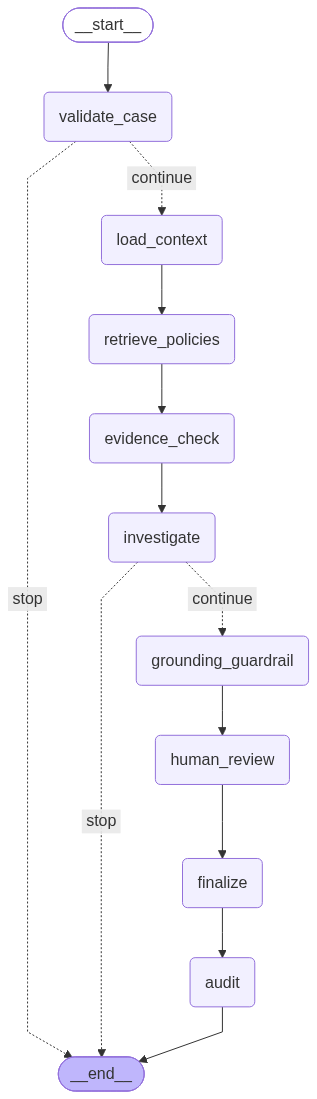

Loaded 8 code cells from Notebook 05. Workflow is ready.


In [1]:
from __future__ import annotations

import json
import statistics
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any
from uuid import uuid4

import pandas as pd
from IPython.display import JSON, display
from pydantic import BaseModel, Field

NOTEBOOK_05 = Path('05_langgraph_workflow.ipynb')
if not NOTEBOOK_05.exists():
    raise FileNotFoundError('Place 05_langgraph_workflow.ipynb in the same folder as Notebook 06.')

source_notebook = json.loads(NOTEBOOK_05.read_text(encoding='utf-8'))
loaded_cells = 0
for cell in source_notebook['cells']:
    if cell['cell_type'] != 'code':
        continue
    cell_source = ''.join(cell['source'])
    if "SELECTED_CASE_ID =" in cell_source:
        break
    exec(compile(cell_source, f'{NOTEBOOK_05}:cell-{loaded_cells}', 'exec'), globals())
    loaded_cells += 1

required_objects = ['workflow', 'datasets', 'chat_model', 'MODEL_PROVIDER', 'MODEL_NAME', 'Command']
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise RuntimeError(f'Notebook 05 bootstrap did not create: {missing_objects}')
print(f'Loaded {loaded_cells} code cells from Notebook 05. Workflow is ready.')

## 2. Evaluation configuration

In [2]:
AVAILABLE_CASE_IDS = sorted(datasets['cases']['case_id'].astype(str).tolist())

# Start with one case. Add more IDs after the first successful run.
EVALUATION_CASE_IDS = ['CASE-3022']
RUN_LLM_JUDGE = False
PASS_THRESHOLD = 0.85
MAX_CASES_PER_RUN = 10

unknown = sorted(set(EVALUATION_CASE_IDS) - set(AVAILABLE_CASE_IDS))
if unknown:
    raise ValueError(f'Unknown evaluation case IDs: {unknown}')
if len(EVALUATION_CASE_IDS) > MAX_CASES_PER_RUN:
    raise ValueError(f'Limit evaluation to {MAX_CASES_PER_RUN} cases per run.')

print('Available:', AVAILABLE_CASE_IDS)
print('Selected:', EVALUATION_CASE_IDS)
print('Optional LLM judge:', RUN_LLM_JUDGE)

Available: ['CASE-3021', 'CASE-3022', 'CASE-3023', 'CASE-3024', 'CASE-3025']
Selected: ['CASE-3022']
Optional LLM judge: False


## 3. Deterministic scoring functions

In [3]:
REQUIRED_RESULT_FIELDS = {
    'case_id', 'issue_type', 'case_summary', 'verified_facts', 'evidence',
    'policy_citations', 'missing_information', 'recommended_action',
    'approval_level', 'confidence', 'requires_human_review',
    'customer_response_draft',
}
SAFE_REVIEW_TERMS = ('pending', 'review', 'approval', 'investigat', 'verify')
EXECUTED_ACTION_TERMS = ('we have refunded', 'refund has been issued', 'payment was reversed', 'case is resolved')

def ratio(numerator: int, denominator: int) -> float:
    return round(numerator / denominator, 4) if denominator else 0.0

def score_deterministically(state: dict[str, Any], expected_case_id: str, elapsed_seconds: float) -> dict[str, Any]:
    result = state.get('investigation', {})
    context = state.get('case_context', {})
    evidence = result.get('evidence', [])
    policies = result.get('policy_citations', [])
    allowed_refs = set(state.get('allowed_reference_ids', []))
    allowed_policies = set(state.get('allowed_policy_ids', []))
    valid_evidence = [item for item in evidence if item.get('reference_id') in allowed_refs]
    valid_policies = [item for item in policies if item.get('document_id') in allowed_policies]
    response = str(result.get('customer_response_draft', '')).lower()
    expected_issue = str(context.get('case', {}).get('issue_type', ''))
    completeness = ratio(sum(bool(result.get(field) or result.get(field) == []) for field in REQUIRED_RESULT_FIELDS), len(REQUIRED_RESULT_FIELDS))
    evidence_precision = ratio(len(valid_evidence), len(evidence))
    policy_precision = ratio(len(valid_policies), len(policies))
    review_language_safe = any(term in response for term in SAFE_REVIEW_TERMS) and not any(term in response for term in EXECUTED_ACTION_TERMS)
    warning_count = len(state.get('warnings', []))
    checks = {
        'case_id_match': result.get('case_id') == expected_case_id,
        'issue_type_match': result.get('issue_type') == expected_issue,
        'human_review_required': result.get('requires_human_review') is True,
        'human_review_completed': bool(state.get('human_decision', {}).get('reviewer_id')),
        'has_evidence': len(evidence) > 0,
        'has_policy_citations': len(policies) > 0,
        'review_language_safe': review_language_safe,
        'audit_complete': all(state.get('audit_record', {}).get(key) for key in ('event_id', 'timestamp_utc', 'case_id', 'reviewer_id', 'decision')),
    }
    hard_pass = all(checks.values()) and evidence_precision == 1.0 and policy_precision == 1.0
    quality_score = round(
        0.20 * completeness +
        0.20 * evidence_precision +
        0.15 * policy_precision +
        0.10 * float(checks['case_id_match']) +
        0.10 * float(checks['issue_type_match']) +
        0.10 * float(checks['human_review_required'] and checks['human_review_completed']) +
        0.10 * float(review_language_safe) +
        0.05 * float(checks['audit_complete']), 4
    )
    return {
        'case_id': expected_case_id,
        'issue_type': expected_issue,
        'final_status': state.get('final_status'),
        'quality_score': quality_score,
        'passed': hard_pass and quality_score >= PASS_THRESHOLD,
        'completeness': completeness,
        'evidence_grounding_precision': evidence_precision,
        'policy_grounding_precision': policy_precision,
        'confidence': result.get('confidence'),
        'warning_count': warning_count,
        'latency_seconds': round(elapsed_seconds, 3),
        **checks,
        'warnings': state.get('warnings', []),
        'error': '',
    }

## 4. Optional independent rubric-based LLM judge

Leave this disabled for the first run. Enabling it adds one model call per evaluated case and therefore adds latency and API cost/quota usage.

In [8]:
class JudgeResult(BaseModel):
    groundedness: float = Field(ge=0, le=1)
    completeness: float = Field(ge=0, le=1)
    action_safety: float = Field(ge=0, le=1)
    customer_response_quality: float = Field(ge=0, le=1)
    rationale: str

def run_llm_judge(state: dict[str, Any]) -> dict[str, Any]:
    judge_prompt = f'''Act as a strict quality evaluator, not as the investigator.
Score only what is supported by the supplied context and policies.
Penalize invented facts, unsupported remedies, missing evidence disclosure, and language implying that a pending action was completed.

CASE CONTEXT:
{json.dumps(state.get('case_context', {}), default=str)}

POLICIES:
{json.dumps(state.get('retrieved_policies', []), default=str)}

INVESTIGATION:
{json.dumps(state.get('investigation', {}), default=str)}'''
    judged = chat_model.with_structured_output(JudgeResult).invoke(judge_prompt)
    values = judged.model_dump()
    values['llm_judge_average'] = round(statistics.mean([
        values['groundedness'], values['completeness'],
        values['action_safety'], values['customer_response_quality'],
    ]), 4)
    return values

## 5. Evaluation runner

Each case receives a unique checkpoint thread. The test reviewer approves the generated draft only so the graph can finish and its audit behavior can be measured.

In [9]:
def evaluate_case(case_id: str) -> tuple[dict[str, Any], dict[str, Any] | None]:
    thread_id = f'eval-{case_id}-{uuid4()}'
    config = {'configurable': {'thread_id': thread_id}}
    started = time.perf_counter()
    try:
        paused = workflow.invoke({'case_id': case_id}, config=config)
        interrupts = paused.get('__interrupt__', [])
        if not interrupts:
            raise RuntimeError(f'Workflow did not pause for human review; status={paused.get("final_status")}')
        review_value = interrupts[0].value
        if review_value.get('case_id') != case_id:
            raise RuntimeError('Human-review payload contains the wrong case ID.')
        simulated_review = {
            'decision': 'approve',
            'reviewer_id': 'EVALUATION-HARNESS',
            'comments': 'Automated resume for regression testing only.',
            'edited_response': None,
        }
        completed = workflow.invoke(Command(resume=simulated_review), config=config)
        elapsed = time.perf_counter() - started
        row = score_deterministically(completed, case_id, elapsed)
        if RUN_LLM_JUDGE:
            row.update(run_llm_judge(completed))
        return row, completed
    except Exception as exc:
        elapsed = time.perf_counter() - started
        return {
            'case_id': case_id, 'passed': False, 'quality_score': 0.0,
            'latency_seconds': round(elapsed, 3), 'error': str(exc),
        }, None

## 6. Run the regression suite

In [10]:
evaluation_rows = []
completed_states = {}

for case_id in EVALUATION_CASE_IDS:
    print(f'Evaluating {case_id} ...')
    row, state = evaluate_case(case_id)
    evaluation_rows.append(row)
    if state is not None:
        completed_states[case_id] = state
    print(f"  passed={row.get('passed')}, score={row.get('quality_score')}, latency={row.get('latency_seconds')}s")

evaluation_df = pd.DataFrame(evaluation_rows)
display(evaluation_df)

Evaluating CASE-3022 ...
  passed=True, score=1.0, latency=3.061s


,case_id,issue_type,final_status,quality_score,passed,completeness,evidence_grounding_precision,policy_grounding_precision,confidence,warning_count,...,case_id_match,issue_type_match,human_review_required,human_review_completed,has_evidence,has_policy_citations,review_language_safe,audit_complete,warnings,error
0,CASE-3022,Duplicate Charge,approved,1.0,True,1.0,1.0,1.0,0.97,0,...,True,True,True,True,True,True,True,True,[],


## 7. Quality gate and summary

In [11]:
total = len(evaluation_df)
passed = int(evaluation_df['passed'].fillna(False).sum()) if total else 0
pass_rate = round(passed / total, 4) if total else 0.0
mean_score = round(float(evaluation_df['quality_score'].fillna(0).mean()), 4) if total else 0.0
mean_latency = round(float(evaluation_df['latency_seconds'].fillna(0).mean()), 3) if total else 0.0
suite_passed = total > 0 and passed == total and mean_score >= PASS_THRESHOLD

summary = {
    'evaluated_at_utc': datetime.now(timezone.utc).isoformat(),
    'provider': MODEL_PROVIDER,
    'model': MODEL_NAME,
    'cases_tested': total,
    'cases_passed': passed,
    'pass_rate': pass_rate,
    'mean_quality_score': mean_score,
    'mean_latency_seconds': mean_latency,
    'pass_threshold': PASS_THRESHOLD,
    'suite_passed': suite_passed,
    'llm_judge_enabled': RUN_LLM_JUDGE,
}
display(JSON(summary))

if suite_passed:
    print('QUALITY GATE: PASSED ✅')
else:
    print('QUALITY GATE: FAILED — inspect failed checks and errors before the demo.')

<IPython.core.display.JSON object>

QUALITY GATE: PASSED ✅


## 8. Inspect one case in detail

In [12]:
INSPECT_CASE_ID = EVALUATION_CASE_IDS[0]
if INSPECT_CASE_ID in completed_states:
    inspected = completed_states[INSPECT_CASE_ID]
    display(JSON({
        'investigation': inspected.get('investigation'),
        'warnings': inspected.get('warnings'),
        'human_decision': inspected.get('human_decision'),
        'audit_record': inspected.get('audit_record'),
    }))
else:
    print(f'No completed state exists for {INSPECT_CASE_ID}; inspect its error in evaluation_df.')

<IPython.core.display.JSON object>

## 9. Export evaluation evidence

In [13]:
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
csv_path = ARTIFACT_DIR / 'notebook06_evaluation_results.csv'
json_path = ARTIFACT_DIR / 'notebook06_evaluation_summary.json'
evaluation_df.to_csv(csv_path, index=False)
json_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
print('Saved:', csv_path.resolve())
print('Saved:', json_path.resolve())

Saved: C:\Users\Administrator\Documents\CX Assist\notebooks\artifacts\notebook06_evaluation_results.csv
Saved: C:\Users\Administrator\Documents\CX Assist\notebooks\artifacts\notebook06_evaluation_summary.json


## Recommended demo sequence

1. Run `CASE-3022` alone and show the metric row.
2. Explain that deterministic grounding and workflow controls are release gates.
3. Expand `EVALUATION_CASE_IDS` to several cases for regression testing.
4. Enable the LLM judge only when you want semantic-quality scoring and have sufficient API quota.
5. Keep automated approval confined to this evaluation notebook.